In [9]:

from ontolearn.owl_neural_reasoner import TripleStoreNeuralReasoner

import time
from typing import Tuple, Set
import pandas as pd
from owlapy import owl_expression_to_dl
from itertools import chain
from argparse import ArgumentParser
import os
from tqdm import tqdm
import random
import itertools
import re
import ast
from owlready2 import get_ontology
import torch


# Set pandas options to ensure full output
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.colheader_justify', 'left')
pd.set_option('display.expand_frame_repr', False)





# Step 1: Load CSV files
def load_csv(file_path):
    """Load a CSV file into a DataFrame."""
    return pd.read_csv(file_path)

def get_entity_df(base_path, pqr, label_na=-1, entity_filter=False):
    # File paths
    #base_path = f"./KGs_Family_family-benchmark_rich_background_owl_{pqr}"
    entities_file = f"{base_path}/DeCaL_entity_embeddings.csv"
    entity_map_file = f"{base_path}/entity_to_idx.p"

    # Load entity embeddings and map
    entities_df = load_csv(entities_file)  # First column is URI
    return entities_df

def process_family_df(df):
    # Regex patterns
    # Corrected regex patterns
    individual_pattern = r'^http://www\.benchmark\.org/family#F\d+.*$'   # Starts with F + digits
    class_pattern = r'^http://www\.benchmark\.org/family#(?!F\d).*'      # Does NOT start with F + digits
    
    
    # Lists to store URIs
    individual_uris = []
    class_uris = []
    
    # Iterate over URIs in the first column
    for uri in df.iloc[:, 0]:
        if re.match(individual_pattern, uri):
            individual_uris.append(uri)
        elif re.match(class_pattern, uri):
            class_uris.append(uri)
        # else: ignore other URIs
    
    # Filter DataFrame to include only individuals and drop the URI column for embeddings
    ind_embeddings_df = df[df.iloc[:, 0].isin(individual_uris)].reset_index(drop=True)
    ind_embeddings = ind_embeddings_df.iloc[:, 1:]
    
    return individual_uris, class_uris, ind_embeddings.to_numpy(), ind_embeddings_df.iloc[:, 0].to_list()


def get_score(clifford_embedding, individuals, classes):
    path = f"/home/iroberts/projects/UPB_UBI/KGs_Family_family-benchmark_rich_background_owl_{clifford_embedding}"

    neural_owl_reasoner = TripleStoreNeuralReasoner(path_neural_embedding=path,gamma=0.1)
    score = neural_owl_reasoner.model.predict(h=individuals, 
                                              r="http://www.w3.org/1999/02/22-rdf-syntax-ns#type", 
                                              t=classes,logits=False)

    return score


def get_relation_df(pqr):
    # File paths
    base_path = f"./KGs_Family_family-benchmark_rich_background_owl_{pqr}"
    relations_file = f"{base_path}/DeCaL_relation_embeddings.csv"

    # Load entity embeddings and map
    relation_df = load_csv(relations_file)  # First column is URI
    return relation_df

def get_relation_type_embedding(df):
    # Regex patterns
    # Corrected regex patterns
    individual_pattern = r'http://www.w3.org/1999/02/22-rdf-syntax-ns#type'   # Starts with F + digits
    
    
    # Lists to store URIs
    individual_uris = []
    class_uris = []
    
    # Iterate over URIs in the first column
    for uri in df.iloc[:, 0]:
        if individual_pattern == uri:
            # print(uri)
            individual_uris.append(uri)
        # else: ignore other URIs
    
    # Filter DataFrame to include only individuals and drop the URI column for embeddings
    type_embedding_df = df[df.iloc[:, 0].isin(individual_uris)].reset_index(drop=True)
    type_embedding = type_embedding_df.iloc[:, 1:]
    #print(type_embedding_df.iloc[:, 0])
    
    return type_embedding.to_numpy()


from dicee.static_funcs import load_model
import numpy as np

# This function will take embeddings and map them to a score for a class
# now I need to find the right
def score(h,t,model):
    r = get_relation_type_embedding(get_relation_df(pqr))
    # print(h.shape)
    # print(t.shape)
    # print(np.array(r.reshape((r.shape[1],))).shape)
    r = r.reshape((r.shape[1],))


    x = torch.cat([torch.LongTensor(h), torch.LongTensor(r), torch.LongTensor(t)])
    # print(x.shape)
    vr = model(x)
    # print(vr)
    return torch.sigmoid(model(x))



def get_class_embeddings(df, class_uris):
    # Filter DataFrame to include only individuals and drop the URI column for embeddings
    class_embeddings_df = df[df.iloc[:, 0].isin(class_uris)].reset_index(drop=True)
    class_embeddings = class_embeddings_df.iloc[:, 1:]
    classes = class_embeddings_df.iloc[:, 0].to_list()
    return class_embeddings.to_numpy(), classes

classes_of_interest = ["http://www.benchmark.org/family#Brother",
                        "http://www.benchmark.org/family#Male",
                         "http://www.benchmark.org/family#PersonWithASibling",
                         "http://www.benchmark.org/family#Child",
                         "http://www.benchmark.org/family#Person",
                         "http://www.benchmark.org/family#Daughter",
                        "http://www.benchmark.org/family#Female",
                        "http://www.benchmark.org/family#Father",
                         "http://www.benchmark.org/family#Parent",
                         "http://www.benchmark.org/family#Grandchild",
                         "http://www.benchmark.org/family#Granddaughter",
                        "http://www.benchmark.org/family#Grandfather",
                         "http://www.benchmark.org/family#Grandparent",
                         "http://www.benchmark.org/family#Grandmother",
                         "http://www.benchmark.org/family#Grandson",
                        "http://www.benchmark.org/family#Mother",
                         "http://www.benchmark.org/family#Sister",
                         "http://www.benchmark.org/family#Son",
]


In [2]:


from dicee.static_funcs import load_model
import numpy as np

def construct_cl_multivector(x: torch.FloatTensor, re: int, p: int, q: int, r: int, model) -> tuple[
        torch.FloatTensor, torch.FloatTensor, torch.FloatTensor]:
        """
        Construct a batch of multivectors Cl_{p,q,r}(\mathbb{R}^d)
        Parameter
        ---------
        x: torch.FloatTensor with (n,d) shape
        Returns
        -------
        a0: torch.FloatTensor
        ap: torch.FloatTensor
        aq: torch.FloatTensor
        ar: torch.FloatTensor
        """
        # x = x.unsqueeze(dim=1).T
        batch_size, d = x.shape

        # (1) A_{n \times k}: take the first k columns
        a0 = x[:, :re].view(batch_size, re)
        # (2) B_{n \times p}, C_{n \times q}: take the self.k * self.p columns after the k. column
        if p > 0:
            ap = x[:, re: re + (re * p)].view(batch_size, re, p)
        else:
            ap = torch.zeros((batch_size, re, p), device=model.device)
        if q > 0:
            # (3) B_{n \times p}, C_{n \times q}: take the last self.r * self.q .
            aq = x[:, re + (re * p):re + (re * p) + (re * q):].view(batch_size, re, q)
        else:
            aq = torch.zeros((batch_size, re, q), device=model.device)
        if r > 0:
            # (3) B_{n \times p}, C_{n \times q}: take the last self.r * self.q .
            ar = x[:, -(re * r):].view(batch_size, re, r)
        else:
            ar = torch.zeros((batch_size, re, r), device=model.device)
        return a0, ap, aq, ar


# This function will take embeddings and map them to a score for a class
# now I need to find the right
def pred_wrapper(h, t, model=None):
    r = get_relation_type_embedding(get_relation_df(pqr))
    r = r.reshape((r.shape[1],))
    #print(r)
    # Repeat r and t for each head entity
    n = h.shape[0]  # number of head entities

    head_ent_emb = torch.FloatTensor(h)  # shape: (n, d)
    rel_ent_emb = torch.FloatTensor(np.tile(r, (n, 1)))  # shape: (n, d)
    tail_ent_emb = torch.FloatTensor(np.tile(t, (n, 1)))  # shape: (n, d)

    # Construct multivectors for each batch element
    h0, hp, hq, hk = construct_cl_multivector(head_ent_emb, re=model.re, p=model.p, q=model.q, r=model.r,model=model)
    r0, rp, rq, rk = construct_cl_multivector(rel_ent_emb, re=model.re, p=model.p, q=model.q, r=model.r,model=model)
    t0, tp, tq, tk = construct_cl_multivector(tail_ent_emb, re=model.re, p=model.p, q=model.q, r=model.r, model=model)


    # h0, hp, hq, hk, h0, rp, rq, rk = self.apply_coefficients(h0, hp, hq, hk, h0, rp, rq,rk)

    # (4) Compute a triple score based on interactions described by the basis 1. 
    h0r0t0 = torch.einsum('br, br -> b', h0 * r0, t0)

    # (5) Compute a triple score based on interactions described by the bases of p {e_1, ..., e_p}.
    if model.p > 0:
        # Second term in Eq.16
        hp_rp_t0 = torch.einsum('brp, br  -> b', hp * rp, t0)
        # Eq. 17
        # b=e
        h0_rp_tp = torch.einsum('brp, erp -> b', torch.einsum('br,  brp -> brp', h0, rp), tp)
        hp_r0_tp = torch.einsum('brp, erp -> b', torch.einsum('brp, br  -> brp', hp, r0), tp)

        score_p = hp_rp_t0 + h0_rp_tp + hp_r0_tp
    else:
        score_p = 0

    # (5) Compute a triple score based on interactions described by the bases of q {e_{p+1}, ..., e_{p+q}}. Eq. 22
    if model.q > 0:
        # Third item in Eq 16.
        hq_rq_t0 = torch.einsum('brq, br  -> b', hq * rq, t0)
        # Eq. 18.
        h0_rq_tq = torch.einsum('br, brq  -> b', h0, rq * tq)
        r0_hq_tq = torch.einsum('br, brq  -> b', r0, hq * tq)
        score_q = - hq_rq_t0 + (h0_rq_tq + r0_hq_tq)
    else:
        score_q = 0

    if model.r > 0:
        # Eq. 18.
        h0_rk_tk = torch.einsum('br, brk  -> b', h0, rk * tk)
        r0_hk_tk = torch.einsum('br, brk  -> b', r0, hk * tk)
        score_r = (h0_rk_tk + r0_hk_tk)
    else:
        score_r = 0

    if model.p >= 2:
        sigma_pp = torch.sum(model.compute_sigma_pp(hp, rp), dim=[1, 2]).squeeze(-1)
    else:
        sigma_pp = 0
    if model.q >= 2:
        sigma_qq = torch.sum(model.compute_sigma_qq(hq, rq), dim=[1, 2]).squeeze(-1)
    else:
        sigma_qq = 0

    if model.r >= 2:
        sigma_rr = torch.sum(model.compute_sigma_qq(hk, rk), dim=[1, 2]).squeeze(-1)
    else:
        sigma_rr = 0

    if model.p >= 2 and model.q >= 2:
        sigma_pq = torch.sum(model.compute_sigma_pq(hp=hp, hq=hq, rp=rp, rq=rq), dim=[1, 2, 3]).squeeze(-1)
    else:
        sigma_pq = 0

    if model.p >= 2 and model.r >= 2:
        sigma_pr = torch.sum(model.compute_sigma_pq(hp=hp, hk=hk, rp=rp, rk=rk), dim=[1, 2, 3]).squeeze(-1)
    else:
        sigma_pr = 0
    if model.q >= 2 and model.r >= 2:
        sigma_qr = torch.sum(model.compute_sigma_pq(hq=hq, hk=hk, rq=rq, rk=rk), dim=[1, 2, 3]).squeeze(-1)
    else:
        sigma_qr = 0

    dot =  h0r0t0 + score_p + score_q + score_r + sigma_pp + sigma_qq + sigma_rr + sigma_pq + sigma_qr + sigma_pr
    prob = torch.sigmoid(dot).numpy()
    # prob = threshold_sigmoid(dot.numpy())

    return np.stack([1-prob, prob], axis=1)

# def threshold_sigmoid(x, gamma=, k=1):
#     return 1 / (1 + np.exp(-k * (x - gamma)))
    

In [3]:
from ontolearn.knowledge_base import KnowledgeBase
from owlapy.class_expression import OWLClass


symbolic_kb = KnowledgeBase(path="/home/robertsi20/PycharmProjects/UPB_UBI/KGs/Family/family-benchmark_rich_background.owl")

def concept_retrieval(retriever_func, c):
    return [i.str for i in retriever_func.individuals(c)]


In [11]:
pqrs = [ "0_0_0", "0_0_1", "0_1_0", "0_1_1", "1_0_0", "1_0_1", "1_1_0", "1_1_1"]

from sklearn.metrics import accuracy_score
import umap
from deepview.fisher_metric import clifford_product_matrix, clifford_to_distance
from deepview.evaluate import leave_one_out_knn_dist_err


class_of_interest = ["http://www.benchmark.org/family#Grandmother"]

for pqr in pqrs:
    print("PQR", pqr)
    kge_path = f"/home/robertsi20/PycharmProjects/UPB_UBI/KGs_Family_modifications_family_modified_grandmother_owl_{pqr}"
    pqr_model, (_,_) = load_model(path_of_experiment_folder=kge_path)        
    _, _, ind_embeddings ,inds = process_family_df(get_entity_df(kge_path,pqr))
    #print(inds[:5])
    #print(ind_embeddings[:5])
    class_embeddings, classes = get_class_embeddings(get_entity_df(kge_path,pqr),classes_of_interest)
    clifford_distance = clifford_to_distance(clifford_product_matrix(ind_embeddings))
    
    
    accuracies = []
    LOO_errors = []
    for i, cl in enumerate(classes):
        predict_with_class = lambda h: pred_wrapper(h, class_embeddings[i], model=pqr_model)
        gt = concept_retrieval(symbolic_kb, OWLClass(classes[i]))
        gt_set = set(gt)
        labels = np.array([1 if ind in gt_set else 0 for ind in inds])
        results = predict_with_class(ind_embeddings)
        y_preds = np.argmax(results,axis=1)

        #umap_embedded = umap.UMAP(metric="precomputed").fit_transform(clifford_distance)

        loo = leave_one_out_knn_dist_err(clifford_distance, y_preds, n_neighbors=5)

        LOO_errors.append(loo)

        accuracies.append(accuracy_score(labels,y_preds))
        

    print("Average Accuracy: ",np.mean(accuracies))
    print("Average QNN Error: ", np.mean(LOO_errors))




PQR 0_0_0
Average Accuracy:  0.6457645764576457
Average QNN Error:  0.0022002200220022
PQR 0_0_1
Average Accuracy:  0.6347634763476347
Average QNN Error:  0.11221122112211221
PQR 0_1_0
Average Accuracy:  0.6999449944994499
Average QNN Error:  0.0913091309130913
PQR 0_1_1
Average Accuracy:  0.663091309130913
Average QNN Error:  0.09845984598459846
PQR 1_0_0
Average Accuracy:  0.3622112211221122
Average QNN Error:  0.009900990099009901
PQR 1_0_1
Average Accuracy:  0.454895489548955
Average QNN Error:  0.2835533553355336
PQR 1_1_0
Average Accuracy:  0.5690319031903192
Average QNN Error:  0.2092959295929593
PQR 1_1_1
Average Accuracy:  0.605060506050605
Average QNN Error:  0.10863586358635863


In [12]:
pqrs = [ "0_0_0", "0_0_1", "0_1_0", "0_1_1", "1_0_0", "1_0_1", "1_1_0", "1_1_1"]

from sklearn.metrics import accuracy_score



class_of_interest = ["http://www.benchmark.org/family#Grandmother"]

for pqr in pqrs:
    print("PQR", pqr)
    kge_path = f"/home/robertsi20/PycharmProjects/UPB_UBI/KGs_Family_modifications_family_modified_grandmother_owl_{pqr}"
    pqr_model, (_,_) = load_model(path_of_experiment_folder=kge_path)        
    _, _, ind_embeddings ,inds = process_family_df(get_entity_df(kge_path,pqr))
    #print(inds[:5])
    #print(ind_embeddings[:5])
    class_embeddings, classes = get_class_embeddings(get_entity_df(kge_path,pqr),class_of_interest)

    #print(classes[0])
    #print(class_embeddings)
    # usage
    # Fix t and model, only vary h
    predict_with_class0 = lambda h: pred_wrapper(h, class_embeddings, model=pqr_model)

    # Call it with embeddings
    results = predict_with_class0(ind_embeddings)
    

    gt=concept_retrieval(symbolic_kb, OWLClass(classes[0]))

    gt_set = set(gt)
    
    
    # Create numpy array with 1 if ind is in gt_set else 0
    labels = np.array([1 if ind in gt_set else 0 for ind in inds])


    print(accuracy_score(labels,np.argmax(results,axis=1)))




PQR 0_0_0
0.8267326732673267
PQR 0_0_1
0.8316831683168316
PQR 0_1_0
0.8267326732673267
PQR 0_1_1
0.7524752475247525
PQR 1_0_0
0.17326732673267325
PQR 1_0_1
0.3118811881188119
PQR 1_1_0
0.7772277227722773
PQR 1_1_1
0.7821782178217822


Error: [Errno 17] File exists: 'Grandmother'
PQR 0_0_0
Embedding samples ...


/home/robertsi20/miniconda3/envs/concept_pd_bi/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/robertsi20/miniconda3/envs/concept_pd_bi/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Computing decision regions ...


/home/robertsi20/PycharmProjects/UPB_UBI/DeepView/deepview/DeepView.py:374: RuntimeWarning: invalid value encountered in divide
  color = self.cmap(self.mesh_classes/mesh_max_class)


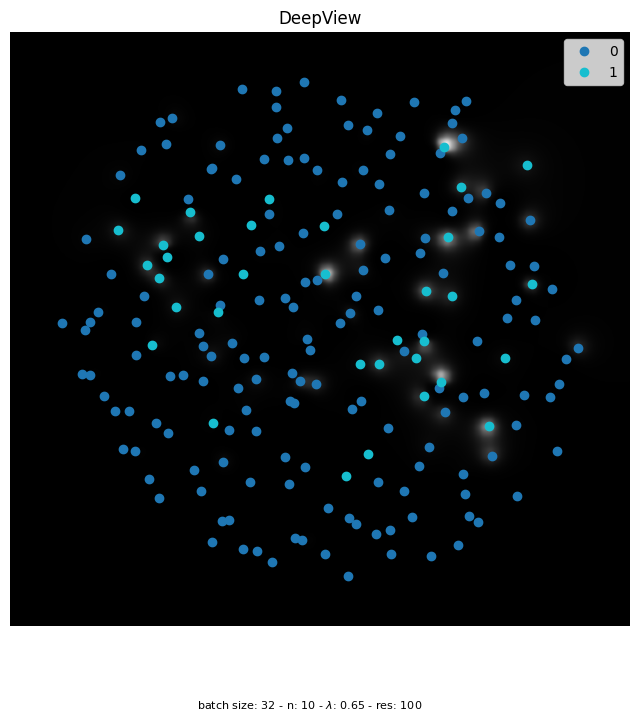

/home/robertsi20/miniconda3/envs/concept_pd_bi/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


PQR 0_0_1
Embedding samples ...


/home/robertsi20/miniconda3/envs/concept_pd_bi/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Computing decision regions ...


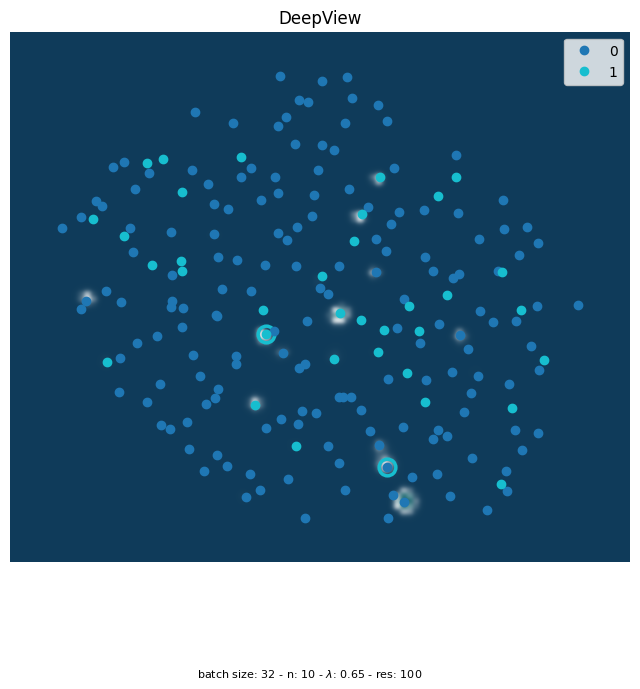

PQR 0_1_0
Embedding samples ...


/home/robertsi20/miniconda3/envs/concept_pd_bi/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/robertsi20/miniconda3/envs/concept_pd_bi/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Computing decision regions ...


/home/robertsi20/PycharmProjects/UPB_UBI/DeepView/deepview/DeepView.py:374: RuntimeWarning: invalid value encountered in divide
  color = self.cmap(self.mesh_classes/mesh_max_class)


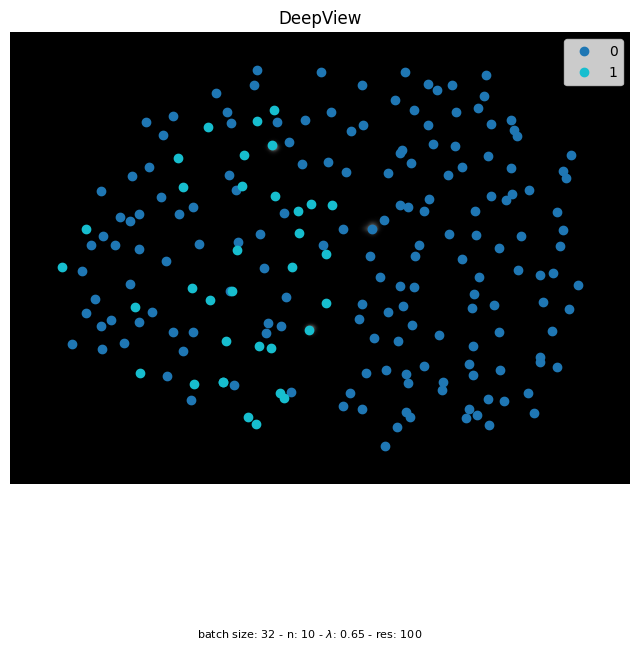

/home/robertsi20/miniconda3/envs/concept_pd_bi/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


PQR 0_1_1
Embedding samples ...


/home/robertsi20/miniconda3/envs/concept_pd_bi/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Computing decision regions ...


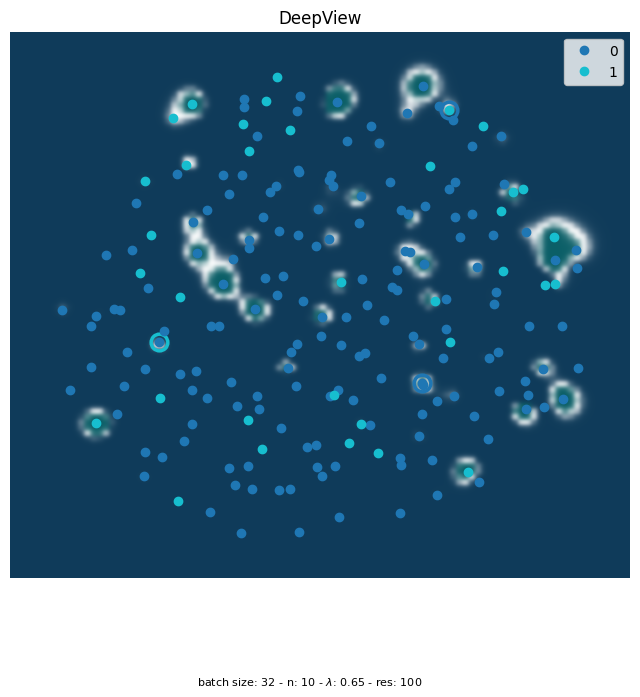

PQR 1_0_0
Embedding samples ...


/home/robertsi20/miniconda3/envs/concept_pd_bi/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/robertsi20/miniconda3/envs/concept_pd_bi/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Computing decision regions ...


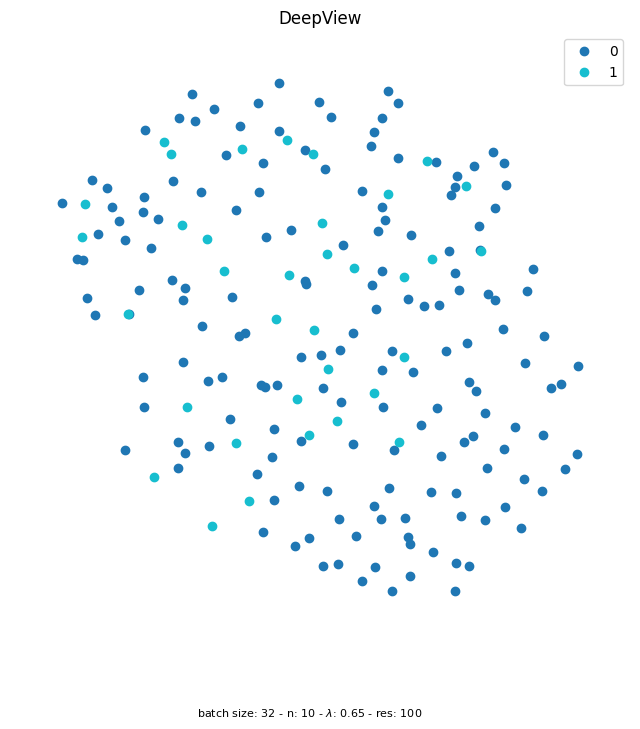

PQR 1_0_1
Embedding samples ...


/home/robertsi20/miniconda3/envs/concept_pd_bi/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/robertsi20/miniconda3/envs/concept_pd_bi/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Computing decision regions ...


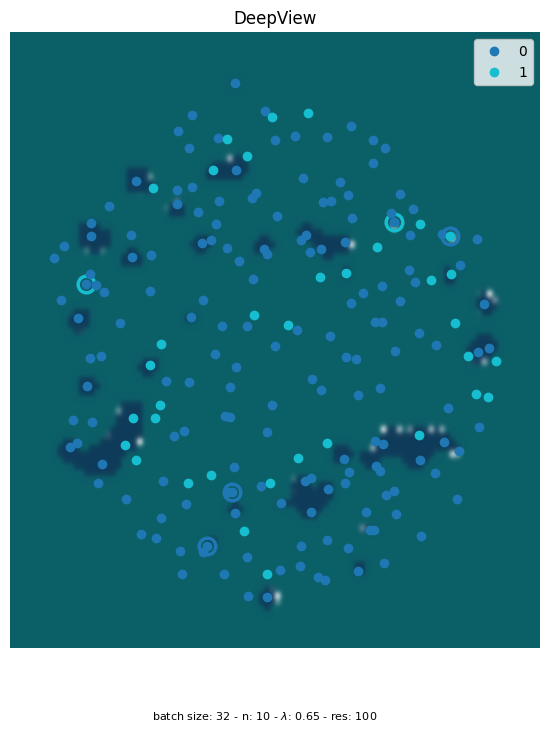

PQR 1_1_0
Embedding samples ...


/home/robertsi20/miniconda3/envs/concept_pd_bi/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/robertsi20/miniconda3/envs/concept_pd_bi/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Computing decision regions ...


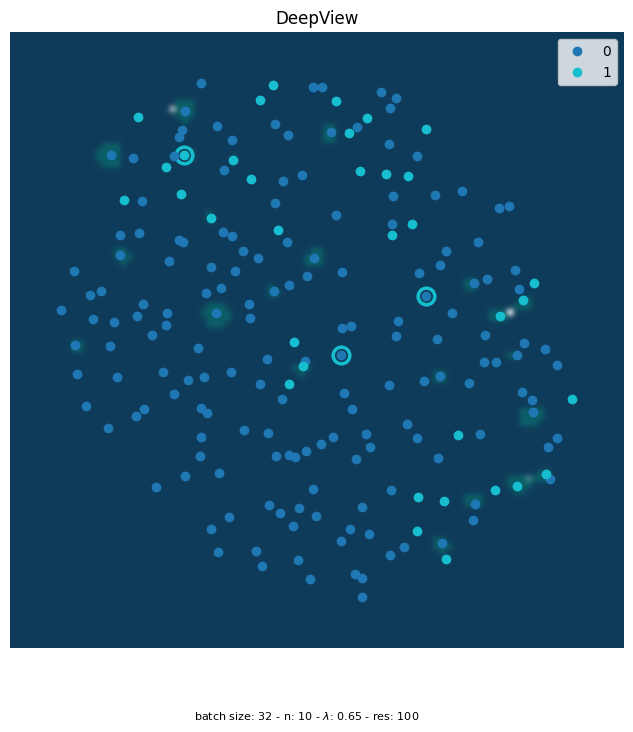

PQR 1_1_1
Embedding samples ...


/home/robertsi20/miniconda3/envs/concept_pd_bi/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/robertsi20/miniconda3/envs/concept_pd_bi/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Computing decision regions ...


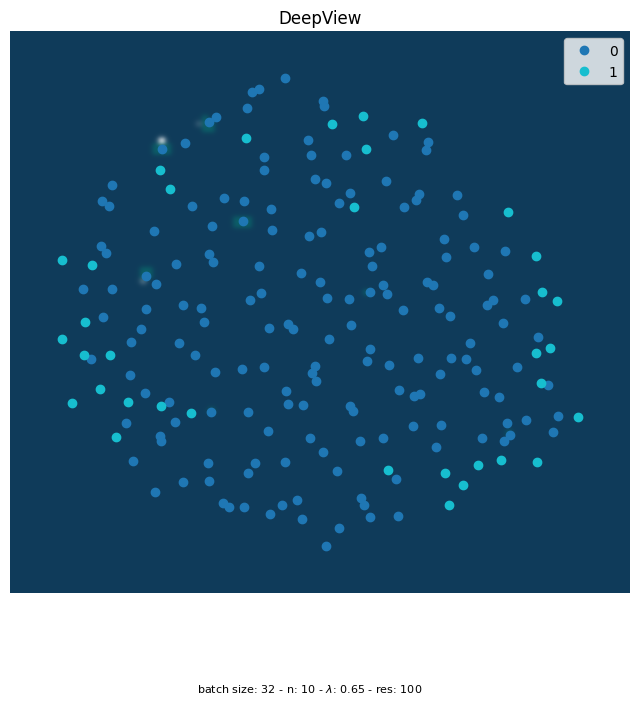

In [13]:
from deepview import DeepView
import numpy as np
import time

import os




# --- Deep View Parameters ----
batch_size = 32
max_samples = 500
data_shape = (32,)
resolution = 100
N = 10
lam = .65
cmap = 'tab10'
# to make shure deepview.show is blocking,
# disable interactive mode
interactive = False
title = 'Male'



uri = "http://www.benchmark.org/family#Grandmother"
class_name = uri.split("#")[-1]   # → "Brother"
class_of_interest = [uri]

dir_path = f"{class_name}"

try:
    os.makedirs(dir_path, exist_ok=False)
except OSError as e:
    print(f"Error: {e}")

all_figures = []

for pqr in pqrs:
    print("PQR", pqr)
    kge_path = f"/home/robertsi20/PycharmProjects/UPB_UBI/KGs_Family_modifications_family_modified_grandmother_owl_{pqr}"
    pqr_model, (_,_) = load_model(path_of_experiment_folder=kge_path)        
    _, _, ind_embeddings, inds = process_family_df(get_entity_df(kge_path,pqr))
    class_embeddings, classes = get_class_embeddings(get_entity_df(kge_path,pqr), class_of_interest)

    predict_with_class = lambda h: pred_wrapper(h, class_embeddings, model=pqr_model)
    gt = concept_retrieval(symbolic_kb, OWLClass(classes[0]))
    gt_set = set(gt)
    labels = np.array([1 if ind in gt_set else 0 for ind in inds])

    deepview = DeepView(
        predict_with_class, np.arange(2), max_samples, batch_size, data_shape, 
        N, lam, resolution, cmap, interactive, title, disc_dist=False
    )
    deepview.add_samples(ind_embeddings, labels)
    
    deepview.show()   # <-- if DeepView supports returning a matplotlib fig
    deepview.fig.savefig(f"{class_name}/deepview_{pqr}_gen_check.png")




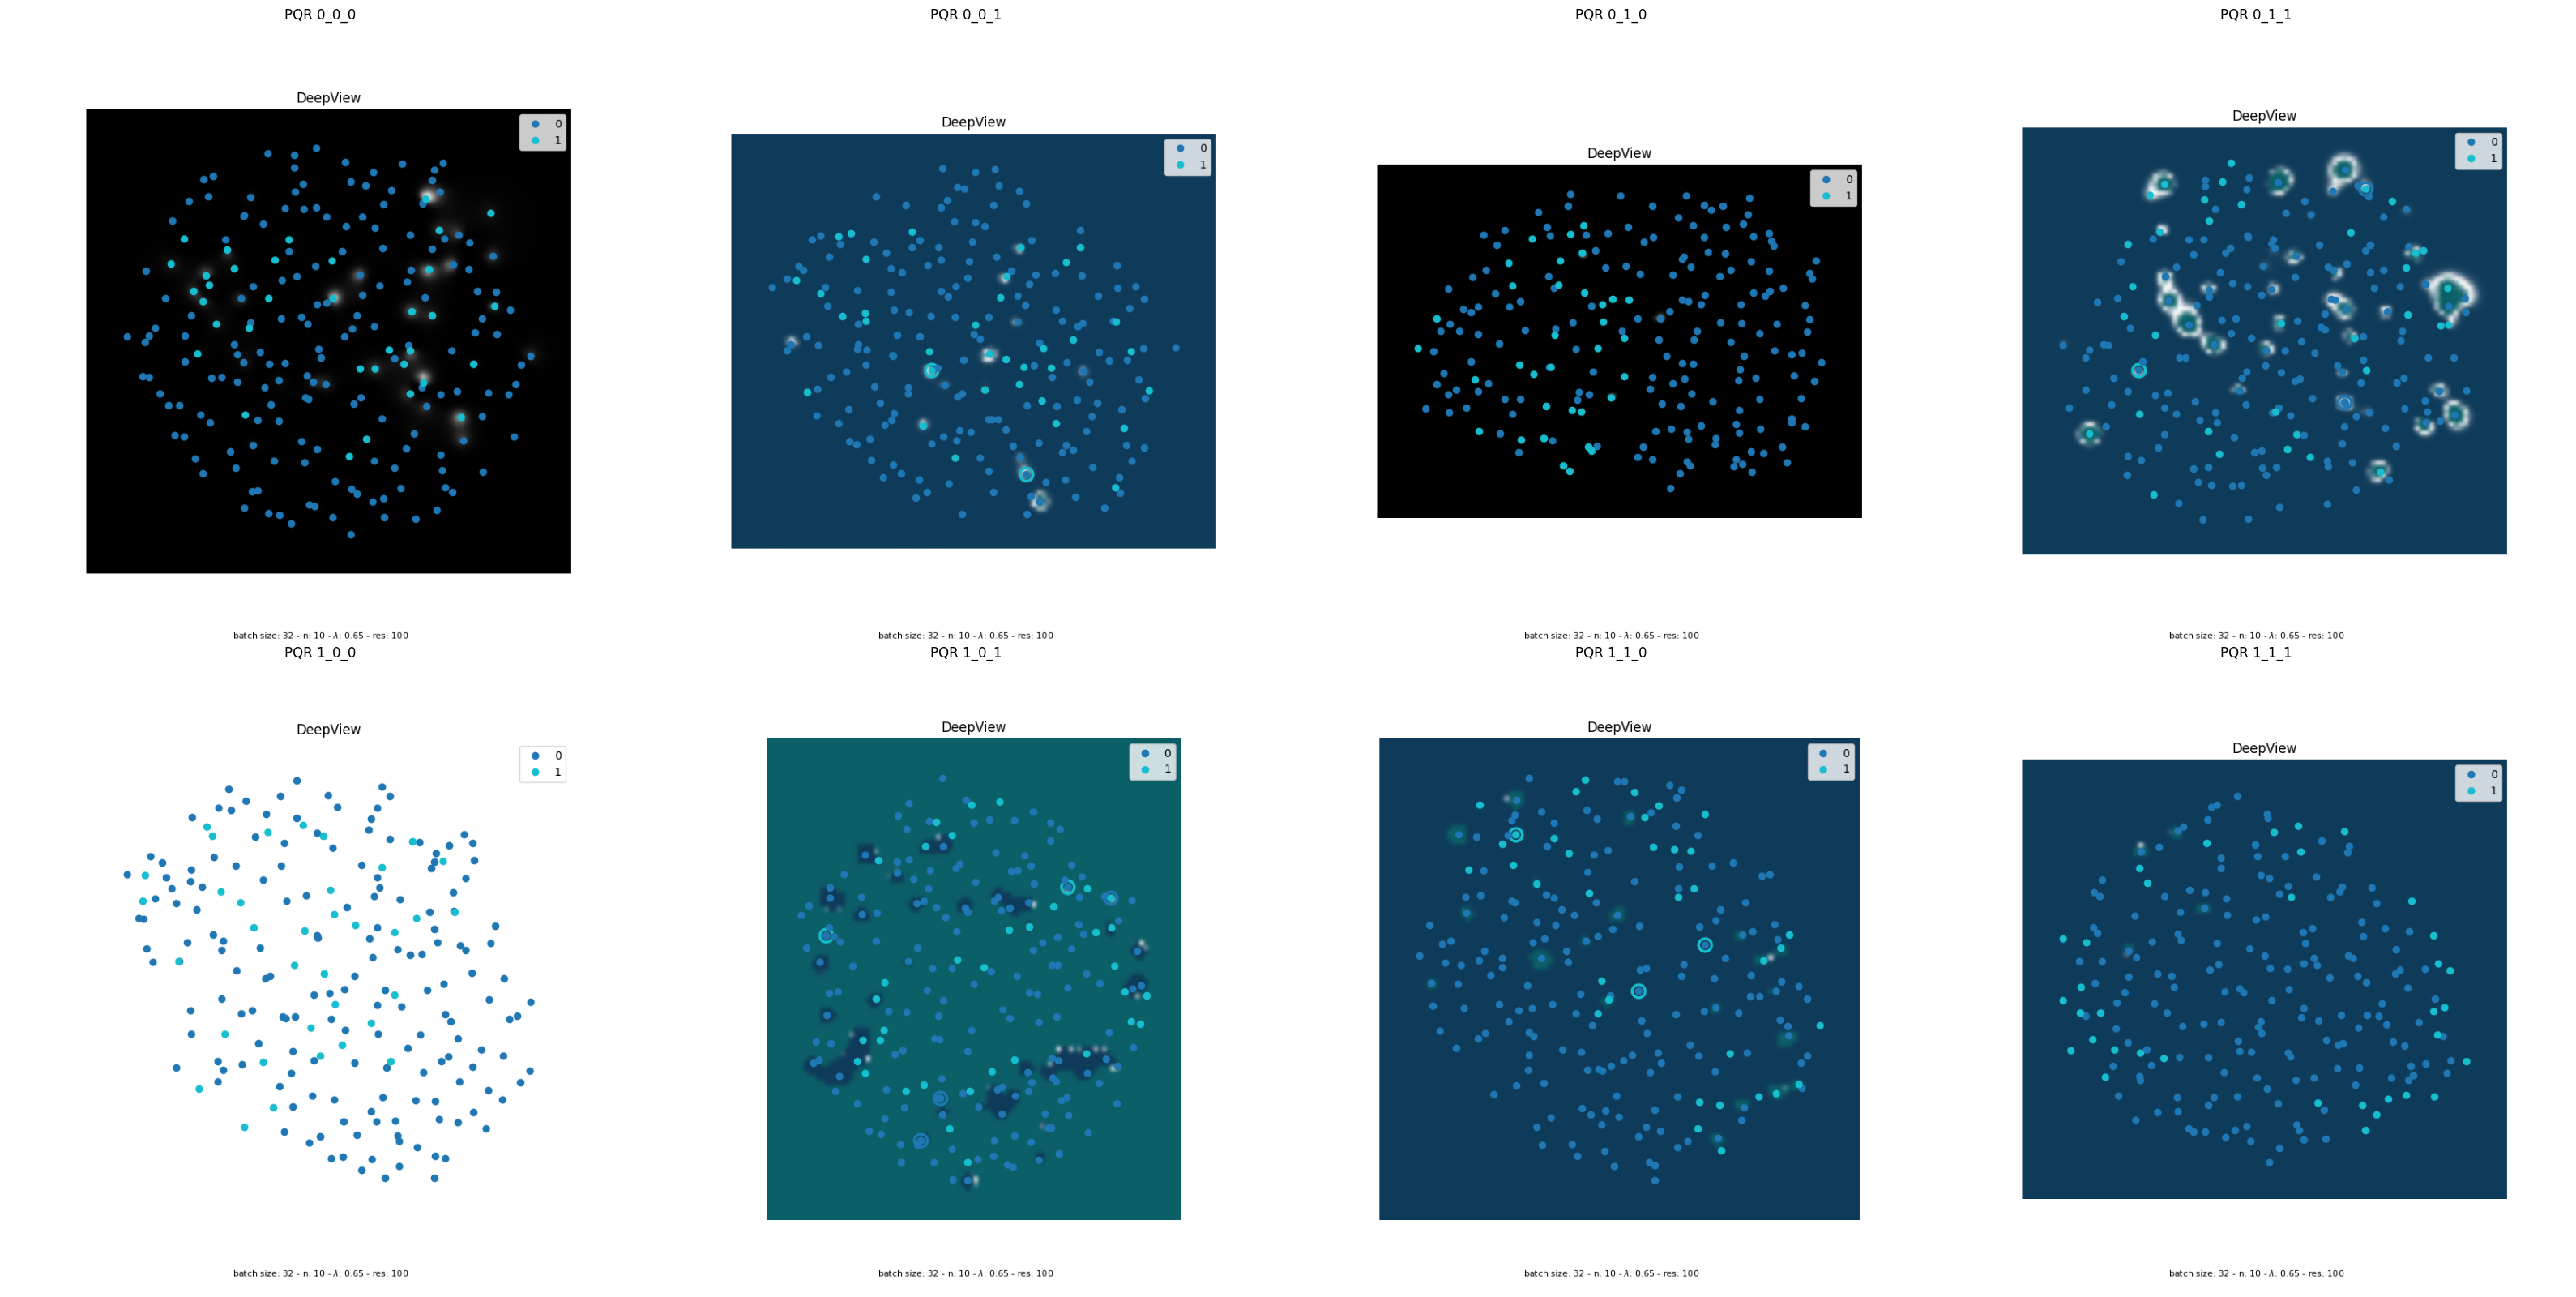

In [14]:
import math
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

class_name = "Grandmother"
n = len(pqrs)
rows = 2
cols = math.ceil(n / rows)

fig, axs = plt.subplots(rows, cols, figsize=(8*cols, 8*rows))  # make bigger by scaling
axs = axs.flatten()  # flatten 2D array of axes into 1D

for ax, pqr in zip(axs, pqrs):
    img = mpimg.imread(f"{class_name}/deepview_{pqr}_gen_check.png")
    ax.imshow(img)
    ax.set_title(f"PQR {pqr}")
    ax.axis("off")

# hide any unused subplots if pqrs is odd
for ax in axs[len(pqrs):]:
    ax.axis("off")

plt.tight_layout()
plt.show()
